<a href="https://colab.research.google.com/github/LeandroD-240/Recommendation_system_practice/blob/main/notebooks/Recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA on the Online Retail Dataset

## Business Understanding

### Business Context

**Wren & Co.** is a UK-based online retailer selling curated home and lifestyle products across 8 categories: Home Decor, Kitchen, Garden, Gifts, Seasonal, Stationery, Textiles, and Toys.

The company holds a full year of transaction history (2025) covering **3,000 customers** and **£2.18M in annual revenue**. Leadership observed that revenue per customer had plateaued despite healthy repeat purchase rates, and suspected customers were not discovering the full product catalogue.

The business question brought to the data team was:

> *"How can we increase revenue per customer without additional marketing spend?"*

---

### Root Cause Analysis — The 5 Whys

The first applied was the **5 Whys** technique to trace the symptom (flat revenue) back to its root cause. This prevents solving the wrong problem.

| # | Question | Answer |
|---|---|---|
| 1 | Why is revenue per customer not growing? | Because average order value and purchase frequency are flat |
| 2 | Why are AOV and frequency flat? | Because customers tend to repurchase from the same categories |
| 3 | Why do customers stay in the same categories? | Because they are not discovering products in complementary categories |
| 4 | Why aren't customers discovering more products? | Because the product page shows no personalised suggestions |
| 5 | Why are there no personalised suggestions? | **Because the company has rich purchase history data but no system to leverage it** |

**Root cause:** A missing intelligence layer. The data exists. The products exist. There is interest on the customers. There is simply no mechanism connecting them.

---

### Business Objective

Design and deploy a **real-time cross-sell recommendation system** that:

- Surfaces 3 personalised product suggestions the moment a customer views any product page
- Uses the customer's own purchase history to personalise recommendations
- Falls back to globally popular products for new customers (cold start)
- Requires no manual curation or ongoing marketing budget

---

### Key Performance Indicators (KPIs)

A KPI is a number tied directly to a business outcome.

| KPI | Formula | Baseline | Target | Why it matters |
|---|---|---|---|---|
| **Revenue per customer** | Total revenue ÷ unique customers | £727.80 | +5.7% → £769 | Primary measure of customer value |
| **Average order value (AOV)** | Total revenue ÷ total invoices | £129.57 | +5% → £136 | Direct lever for cross-sell impact |
| **Repeat purchase rate** | Customers with 2+ orders ÷ all customers | 81.2% | +3pp → 84.2% | Measures retention and re-engagement |
| **Catalogue diversity** | Avg distinct categories per customer | 4.7 / 8 | +0.5 categories | Shows whether discovery is improving |

---

### Business Levers

Business levers are the specific actions the recommendation system enables. Each lever maps directly to one or more KPIs.

| Lever | Mechanism | KPI impacted |
|---|---|---|
| **Cross-sell** | Show complementary products at point of decision | AOV, items per order |
| **Product discovery** | Surface catalogue items customers have never bought | Category diversity |
| **Re-engagement** | Recommend relevant products to customers who have gone quiet | Repeat purchase rate |
| **Catalogue coverage** | Ensure long-tail products get recommended, not just top sellers | Revenue spread |

---

### Is This a Data Science Problem?

Not every business problem requires machine learning. The problem was validate before building anything.

| Gate | Question | Answer |
|---|---|---|
| ✅ Data availability | Do we have enough historical data to learn from? | Yes — 59,052 transactions across 16,851 invoices |
| ✅ Pattern complexity | Is the pattern too complex for manual rules? | Yes — 80 SKUs produce 3,160 unique pair combinations |
| ✅ Actionable output | Does a better prediction lead to a better business decision? | Yes — which 3 products to show drives a direct add-to-basket action |
| ✅ Measurable impact | Can we measure whether it worked? | Yes — AOV and repeat rate can be A/B tested |
| ✅ Operational fit | Can the output be deployed into the product? | Yes — a REST API integrates directly into the product page |

**Conclusion:** All five gates pass. This is a genuine data science problem where a model adds value that rules, intuition, or manual curation cannot replicate at scale.

---

### Success Criteria

The project is considered successful if:

1. **Technical:** The recommendation API returns 3 results for every product click in under 100ms, with 100% uptime of the fallback mechanism
2. **Statistical:** A/B test shows AOV uplift ≥ £6.48 with p-value < 0.05 (95% confidence) over a 77-day test period
3. **Business:** Projected annual revenue uplift of **£127,537** is within 20% of observed uplift in the A/B test

## Data Understanding

> We will examine the data available to us: where it comes from, what it contains, what its limitations are, and whether it is sufficient to answer the business question.

---

### Dataset Origin

The data used in this project is based on the **Online Retail II** dataset published by the UCI Machine Learning Repository.

> 📎 **Source:** Chen, D. (2019). *Online Retail II*. UCI Machine Learning Repository.  
> **URL:** [https://archive.ics.uci.edu/dataset/502/online+retail+ii](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> **License:** Creative Commons Attribution 4.0 International (CC BY 4.0)

### Important note on data simulation

The dataset in this project is **not** the raw UCI file. It was **synthetically regenerated** using the original as a structural and statistical reference, then manipulated with AI assistance to simulate a realistic job scenario. Specifically:

| Modification | Reason |
|---|---|
| Product catalogue reduced to **80 curated SKUs** across 8 categories | Simplifies the recommendation problem to a demonstrable scale |
| Customer base set to **3,000 accounts** with RFM-based behaviour tiers | Reflects real purchasing patterns (Champions, Loyal, At Risk, New, Lost) |
| Transactions generated with **category affinity weights** | Makes cross-sell rules learnable — customers prefer certain categories |
| Date range fixed to **Jan–Dec 2025** | Provides a clean, single-year analytical window |
| Loaded into **SQLite** rather than a flat CSV | Simulates a real production database environment |

This approach was chosen deliberately: the UCI dataset alone would not produce the right density of association rules for a cross-sell use case at a small catalogue scale. The simulation preserves the statistical properties of real retail data while being purpose-built for this analytical scenario.

---

### Database Schema

The data is stored in a **SQLite relational database** (`retail.db`) with 4 normalised tables. This mirrors a real e-commerce production schema where orders, customers, and products are stored separately and joined at query time.

### Entity Relationship Overview

```
customers ──< invoices ──< invoice_items >── products
   (1)          (N)              (N)            (1)
```

Each customer can have many invoices. Each invoice can have many line items. Each line item references one product.

---

### Table: `customers`

Stores one row per unique customer account.

| Column | Type | Constraints | Description |
|---|---|---|---|
| `customer_id` | INTEGER | PRIMARY KEY | Unique customer identifier (10000–12999) |
| `country` | TEXT | NOT NULL | Customer country of residence |

**Row count:** 3,000  
**Key insight:** 65% of customers are UK-based, reflecting the original UCI dataset's geographic distribution.

```sql
SELECT country, COUNT(*) as n
FROM customers
GROUP BY country
ORDER BY n DESC
LIMIT 5;
-- United Kingdom: 1,950 · Germany: 240 · France: 210 · Ireland: 120 · Netherlands: 90
```

---

### Table: `products`

Master catalogue of all 80 available SKUs.

| Column | Type | Constraints | Description |
|---|---|---|---|
| `stock_code` | TEXT | PRIMARY KEY | Unique product code (5-digit numeric string) |
| `description` | TEXT | NOT NULL | Product name in uppercase (used as key in rules engine) |
| `category` | TEXT | NOT NULL | One of 8 categories |
| `unit_price` | REAL | NOT NULL | Price in GBP (£) |

**Row count:** 80  
**Categories:** Garden, Gifts, Home Decor, Kitchen, Seasonal, Stationery, Textiles, Toys  
**Price range:** £1.95 (Ribbon Spool) — £24.95 (Throw Blanket)

```sql
SELECT category, COUNT(*) as skus, ROUND(AVG(unit_price),2) as avg_price
FROM products
GROUP BY category
ORDER BY avg_price DESC;
```

---

### Table: `invoices`

One row per order (invoice). Links customers to their purchases via a date-stamped transaction record.

| Column | Type | Constraints | Description |
|---|---|---|---|
| `invoice_no` | TEXT | NOT NULL | Unique order identifier (6-digit string) |
| `customer_id` | INTEGER | NOT NULL, FK → customers | The customer who placed the order |
| `invoice_date` | TEXT | NOT NULL | Date of purchase (ISO 8601: YYYY-MM-DD) |

**Row count:** 16,851  
**Date range:** 2025-01-01 → 2025-12-31  
**Indexes:** `idx_inv_customer` on `customer_id`

```sql
-- Orders per customer distribution
SELECT
    MIN(order_count) as min_orders,
    ROUND(AVG(order_count),1) as avg_orders,
    MAX(order_count) as max_orders
FROM (
    SELECT customer_id, COUNT(*) as order_count
    FROM invoices
    GROUP BY customer_id
);
-- min: 1 · avg: 5.6 · max: 20
```

---

### Table: `invoice_items`

The transaction grain — one row per product per invoice. This is the table used to build the transaction matrix for the Apriori algorithm.

| Column | Type | Constraints | Description |
|---|---|---|---|
| `id` | INTEGER | PRIMARY KEY, AUTOINCREMENT | Surrogate key |
| `invoice_no` | TEXT | NOT NULL, FK → invoices | Parent invoice |
| `stock_code` | TEXT | NOT NULL, FK → products | Product purchased |
| `quantity` | INTEGER | NOT NULL | Units purchased |
| `unit_price` | REAL | NOT NULL | Price at time of purchase |
| `revenue` | REAL | NOT NULL | Computed: quantity × unit_price |

**Row count:** 59,052  
**Indexes:** `idx_items_invoice` on `invoice_no`, `idx_items_sku` on `stock_code`

```sql
-- Average basket size
SELECT ROUND(AVG(items_per_order), 2) as avg_basket_size
FROM (
    SELECT invoice_no, SUM(quantity) as items_per_order
    FROM invoice_items
    GROUP BY invoice_no
);
-- avg_basket_size: 13.35
```

---

### Dataset Summary Statistics

| Metric | Value |
|---|---|
| Total customers | 3,000 |
| Total invoices (orders) | 16,851 |
| Total line items | 59,052 |
| Unique SKUs | 80 |
| Product categories | 8 |
| Total revenue | £2,183,412.25 |
| Revenue per customer (avg) | £727.80 |
| Average order value (AOV) | £129.57 |
| Avg items per order (qty) | 13.35 |
| Avg categories per customer | 4.73 / 8 |
| Repeat purchase rate | 81.2% |
| Date range | Jan 2025 – Dec 2025 |

---

### Known Limitations

Being transparent about data limitations is a mark of analytical rigour. Stakeholders and reviewers should be aware of the following:

| Limitation | Impact | Mitigation |
|---|---|---|
| Data is synthetic | Rules reflect simulated, not real, purchase behaviour | Statistical properties mirror the UCI source; patterns are internally consistent |
| No product returns or cancellations | Revenue figures are slightly overstated vs. real retail | Acceptable for a proof-of-concept; add a `returns` table in production |
| No seasonal restocking or stockouts | Availability is assumed unlimited | Not relevant for the recommendation task |
| Single currency (GBP) | Multi-currency not modelled | Scope decision; extend with FX table if needed |

---

## Data Preparation (EDA)

### Data Collection

In [ ]:
# Libraries
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, inspect, text
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import pickle

# Warnings
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter('ignore', DeprecationWarning)

In [ ]:
# Connect to the database
engine = create_engine("sqlite:///retail.db")

# Watch the tables available
inspector = inspect(engine)
print("Tables in the database")
print(inspector.get_table_names())

Tables in the database
['customers', 'invoice_items', 'invoices', 'products']


### Data Cleaning

In [ ]:
# Overview of each table
for table in inspector.get_table_names():
  print("\n"*4)
  print(pd.read_sql_table(table, engine.connect()).head())






   customer_id         country
0        10000           Spain
1        10001         Belgium
2        10002         Ireland
3        10003  United Kingdom
4        10004          France





   id invoice_no stock_code  quantity  unit_price  revenue
0   1     500001      21670         6       11.95    71.70
1   2     500002      21833         5        5.75    28.75
2   3     500002      22370         6       15.95    95.70
3   4     500002      22073         2        2.50     5.00
4   5     500002      21332         5        9.50    47.50





  invoice_no  customer_id invoice_date
0     500001        10000   2025-01-22
1     500002        10000   2025-02-21
2     500003        10000   2025-03-11
3     500004        10000   2025-04-09
4     500005        10000   2025-05-15





  stock_code         description    category  unit_price
0      20091   CANDLE HOLDER SET  Home Decor        4.95
1      20115    METAL WALL CLOCK  Home Decor       12.50
2      20128     PHOTO FRAME SET  H

In [ ]:
# Getting each table to a dataframe
df_customers = pd.read_sql_table("customers", engine.connect())
df_invoice_items = pd.read_sql_table("invoice_items", engine.connect())
df_invoices = pd.read_sql_table("invoices", engine.connect())
df_products = pd.read_sql_table("products", engine.connect())

**Checking each table to join them all**

In [ ]:
# Customers observations
df_customers.shape

(3000, 2)

In [ ]:
# Checking of IDs are unique
df_customers["customer_id"].nunique()

3000

In [ ]:
# Matching with invoices
df_invoices["customer_id"].nunique()

3000

In [ ]:
# First join
df_table_1 = df_customers.join(df_invoices.set_index("customer_id"), on="customer_id")
df_table_1.head()

,customer_id,country,invoice_no,invoice_date
0,10000,Spain,500001,2025-01-22
0,10000,Spain,500002,2025-02-21
0,10000,Spain,500003,2025-03-11
0,10000,Spain,500004,2025-04-09
0,10000,Spain,500005,2025-05-15


In [ ]:
# Checking items observations
df_invoice_items.shape

(59052, 6)

In [ ]:
# Checking if IDs are unique
df_invoice_items.invoice_no.nunique()

16851

In [ ]:
# Matching with the joined table
df_table_1.invoice_no.nunique()

16851

In [ ]:
# Second join
df_table_2 = df_table_1.join(df_invoice_items.set_index("invoice_no"), "invoice_no")
df_table_2.head()

,customer_id,country,invoice_no,invoice_date,id,stock_code,quantity,unit_price,revenue
0,10000,Spain,500001,2025-01-22,1,21670,6,11.95,71.70
0,10000,Spain,500002,2025-02-21,2,21833,5,5.75,28.75
0,10000,Spain,500002,2025-02-21,3,22370,6,15.95,95.70
0,10000,Spain,500002,2025-02-21,4,22073,2,2.50,5.00
0,10000,Spain,500002,2025-02-21,5,21332,5,9.50,47.50


In [ ]:
# Products observations
df_products.shape

(80, 4)

In [ ]:
# Checking if IDs are unique
df_products.stock_code.nunique()

80

In [ ]:
# Last join (dataframe to clean and check)
df = df_table_2.join(
    df_products.set_index("stock_code").drop("unit_price", axis=1), "stock_code"
    ).reset_index(drop=True)

# See the results
df.head()

,customer_id,country,invoice_no,invoice_date,id,stock_code,quantity,unit_price,revenue,description,category
0,10000,Spain,500001,2025-01-22,1,21670,6,11.95,71.70,DESK ORGANISER,Stationery
1,10000,Spain,500002,2025-02-21,2,21833,5,5.75,28.75,WASHI TAPE SET,Stationery
2,10000,Spain,500002,2025-02-21,3,22370,6,15.95,95.70,LUXURY NOTEBOOK,Gifts
3,10000,Spain,500002,2025-02-21,4,22073,2,2.50,5.00,GIFT BAG LARGE,Gifts
4,10000,Spain,500002,2025-02-21,5,21332,5,9.50,47.50,GARDEN KNEELER,Garden


In [ ]:
# Checking missing data
df.isnull().sum()

,0
customer_id,0
country,0
invoice_no,0
invoice_date,0
id,0
stock_code,0
quantity,0
unit_price,0
revenue,0
description,0


In [ ]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Checking data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59052 entries, 0 to 59051
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   59052 non-null  int64  
 1   country       59052 non-null  object 
 2   invoice_no    59052 non-null  object 
 3   invoice_date  59052 non-null  object 
 4   id            59052 non-null  int64  
 5   stock_code    59052 non-null  object 
 6   quantity      59052 non-null  int64  
 7   unit_price    59052 non-null  float64
 8   revenue       59052 non-null  float64
 9   description   59052 non-null  object 
 10  category      59052 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 5.0+ MB


In [ ]:
# Basic statistics (quantitatives)
df.describe()

,customer_id,id,quantity,unit_price,revenue
count,59052.000000,59052.000000,59052.000000,59052.000000,59052.000000
mean,11488.049042,29526.500000,3.809473,9.546804,36.974400
std,863.522902,17046.988385,1.950764,4.985537,29.805735
min,10000.000000,1.000000,1.000000,1.950000,1.950000
25%,10734.000000,14763.750000,2.000000,5.500000,15.600000
50%,11497.000000,29526.500000,4.000000,8.750000,28.500000
75%,12210.000000,44289.250000,5.000000,12.750000,49.750000
max,12999.000000,59052.000000,8.000000,24.950000,199.600000


In [ ]:
# Calculate IQR
q1_revenue = df['revenue'].quantile(0.25)
q3_revenue = df['revenue'].quantile(0.75)
iqr_revenue = q3_revenue - q1_revenue

# Ranges
lower_hence = q1_revenue - 1.5 * iqr_revenue
upper_hence = q3_revenue + 1.5 * iqr_revenue

# Checking possible outliers
df[(df["revenue"] < lower_hence) | (df["revenue"] > upper_hence)]

,customer_id,country,invoice_no,invoice_date,id,stock_code,quantity,unit_price,revenue,description,category
41,10002,Ireland,500013,2025-01-18,42,20398,7,14.50,101.50,DOOR WREATH,Home Decor
43,10002,Ireland,500013,2025-01-18,44,20674,8,14.95,119.60,SPICE RACK,Kitchen
69,10002,Ireland,500021,2025-07-05,70,24085,8,19.95,159.60,QUILTED BAG,Textiles
81,10002,Ireland,500025,2025-08-27,82,23553,6,24.95,149.70,THROW BLANKET,Textiles
82,10002,Ireland,500026,2025-09-04,83,23428,8,13.75,110.00,PAINT SET,Toys
...,...,...,...,...,...,...,...,...,...,...,...
59003,12997,United Kingdom,516840,2025-03-10,59004,23450,8,15.95,127.60,BUILDING BLOCKS,Toys
59010,12997,United Kingdom,516841,2025-03-30,59011,20674,8,14.95,119.60,SPICE RACK,Kitchen
59027,12997,United Kingdom,516846,2025-07-03,59028,20398,8,14.50,116.00,DOOR WREATH,Home Decor
59033,12997,United Kingdom,516847,2025-07-18,59034,22229,8,14.50,116.00,BATH BOMB SET,Gifts


In [ ]:
# Checking qualitative columns
df.describe(include=["object"])

,country,invoice_no,invoice_date,stock_code,description,category
count,59052,59052,59052,59052,59052,59052
unique,15,16851,365,80,80,8
top,United Kingdom,516832,2025-02-26,22094,RIBBON SPOOL,Gifts
freq,37199,6,378,1153,1153,11071


In [ ]:
# Checking category
df.category.value_counts()

,count
category,
Gifts,11071
Kitchen,9246
Stationery,8131
Seasonal,7097
Home Decor,7070
Textiles,5983
Garden,5314
Toys,5140


In [ ]:
# Checking country
df.country.value_counts()

,count
country,
United Kingdom,37199
Germany,4525
France,4209
Ireland,2416
Netherlands,2087
Belgium,1320
USA,1199
Portugal,1152
Spain,949


In [ ]:
# Changing invoice date to the correct type
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
df["invoice_date"]

,invoice_date
0,2025-01-22
1,2025-02-21
2,2025-02-21
3,2025-02-21
4,2025-02-21
...,...
59047,2025-01-11
59048,2025-01-11
59049,2025-01-11
59050,2025-01-11


### Data visualization

In [ ]:
# Palette of colors
C_MAIN   = "#01386A"
C_SECOND = "#A188A6"
C_THIRD  = "#BEEF9E"

In [ ]:
# Main KPIs
total_rev     = df["revenue"].sum()
rpc           = df.groupby("customer_id")["revenue"].sum().mean()
aov           = df.groupby("invoice_no")["revenue"].sum().mean()
order_counts  = df.groupby("customer_id")["invoice_no"].nunique()
repeat_rate   = (order_counts > 1).mean() * 100

kpis = [
    ("Revenue per customer", f"£{rpc:,.2f}", ""),
    ("Avg order value",      f"£{aov:,.2f}", "spend per invoice"),
    ("Repeat purchase rate", f"{repeat_rate:.1f}%", "customers with 2+ orders"),
    ("Total revenue",        f"£{total_rev/1_000_000:.2f}M", "Jan–Dec 2025"),
]

[]

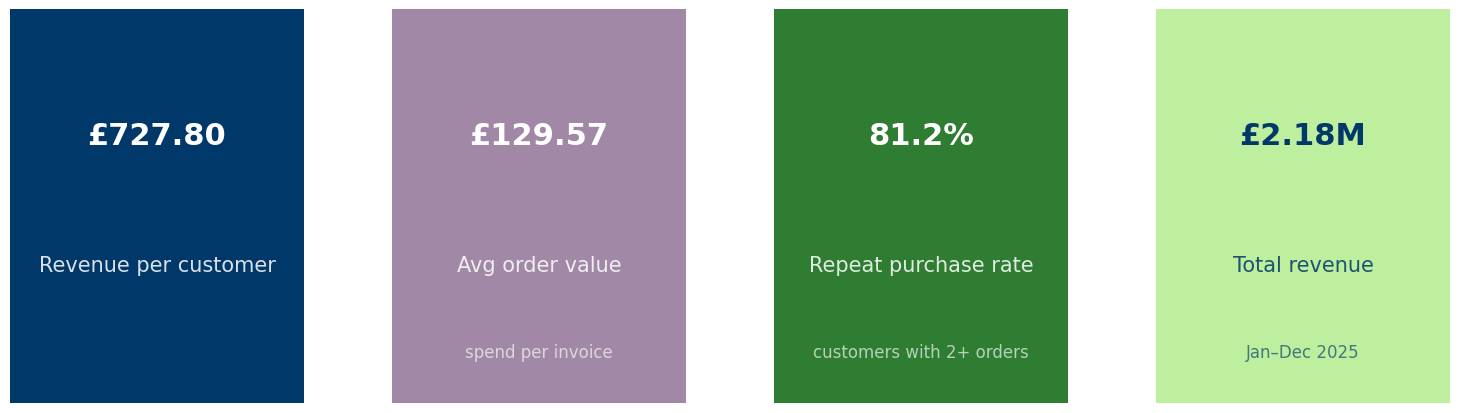

In [ ]:
# Showcase of KPIs
box_colors  = [C_MAIN, C_SECOND, "#2E7D32", C_THIRD]
text_colors = ["white", "white", "white", C_MAIN]

fig = plt.figure(figsize=(16, 18))
fig.patch.set_facecolor("white")

# Row heights: KPI strip (small) + 3 chart rows
gs = fig.add_gridspec(
    3, 2,
    height_ratios=[1.1, 1.1, 1.0],
    hspace=0.55,
    wspace=0.35,
    top=0.93, bottom=0.06,
    left=0.07, right=0.97,
)

# KPI boxes
gs_kpi = gs[0, :].subgridspec(1, 4, wspace=0.3)
kpi_axes = [fig.add_subplot(gs_kpi[0, k]) for k in range(4)]

for ax, (label, value, sub), bg, tc in zip(kpi_axes, kpis, box_colors, text_colors):
    ax.set_facecolor(bg)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.text(0.5, 0.68, value,  ha="center", va="center",
            fontsize=22, fontweight="bold", color=tc, transform=ax.transAxes)
    ax.text(0.5, 0.35, label,  ha="center", va="center",
            fontsize=15, color=tc, alpha=0.85, transform=ax.transAxes)
    ax.text(0.5, 0.13, sub,    ha="center", va="center",
            fontsize=12,  color=tc, alpha=0.65, transform=ax.transAxes)

plt.savefig("Main KPIs.png")
plt.plot()

[]

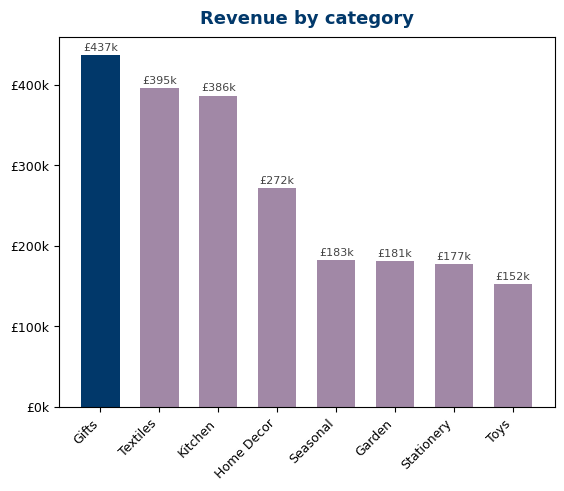

In [ ]:
# Revenue by category
cat_rev = (df.groupby("category")["revenue"]
             .sum()
             .sort_values(ascending=False)
             .reset_index()
             )

# Category colors
CATEGORY_COLORS = {
    "Gifts":       C_MAIN,
    "Textiles":    C_SECOND,
    "Kitchen":     C_SECOND,
    "Home Decor":  C_SECOND,
    "Seasonal":    C_SECOND,
    "Garden":      C_SECOND,
    "Stationery":  C_SECOND,
    "Toys":        C_SECOND,
}

# Show the england coin symbol (the coin is a pound sterling)
def gbp_k(val, pos=None):
    """Format axis tick as £NNNk."""
    return f"£{int(val/1000)}k"

# Showcase
fig, ax_cat = plt.subplots()

bar_colors_cat = [CATEGORY_COLORS.get(c, C_MAIN) for c in cat_rev["category"]]
bars = ax_cat.bar(cat_rev["category"], cat_rev["revenue"],
                  color=bar_colors_cat, width=0.65, zorder=2)

ax_cat.yaxis.set_major_formatter(mticker.FuncFormatter(gbp_k))
ax_cat.set_xticks(range(len(cat_rev)))
ax_cat.set_xticklabels(cat_rev["category"], rotation=45, ha="right", fontsize=9)
ax_cat.tick_params(axis="y", labelsize=9)
ax_cat.set_xlabel("")
ax_cat.set_ylabel("")
ax_cat.set_title("Revenue by category", fontsize=13, fontweight="bold",
                 color=C_MAIN, pad=10)

# Value labels on bars
for bar in bars:
    h = bar.get_height()
    ax_cat.text(bar.get_x() + bar.get_width()/2, h + 3500,
                f"£{h/1000:.0f}k", ha="center", va="bottom",
                fontsize=8, color="#444444")

plt.savefig("Revenue by category.png")
plt.plot()

[]

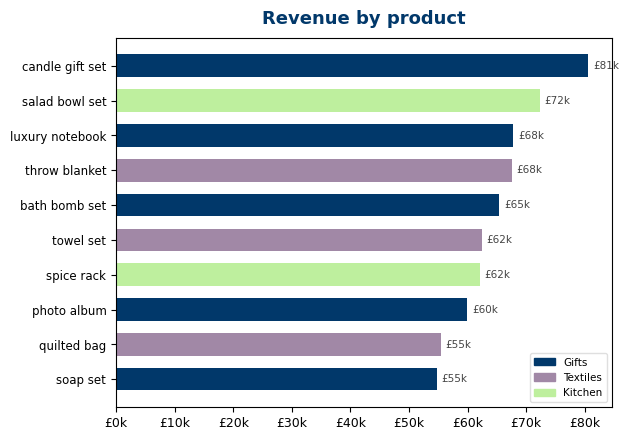

In [ ]:
# Revenue by product
prod_rev = (df.groupby(["description","category"])["revenue"]
              .sum()
              .reset_index()
              .sort_values("revenue", ascending=False)
              .head(10)
              .sort_values("revenue")
              )

# Product colors
PRODUCT_COLORS = {
    "Gifts": C_MAIN,
    "Textiles": C_SECOND,
    "Kitchen": C_THIRD
}

# Showcase
fig, ax_prod = plt.subplots()

prod_colors = [PRODUCT_COLORS.get(c, C_MAIN) for c in prod_rev["category"]]
h_bars = ax_prod.barh(prod_rev["description"].str.lower(),
                      prod_rev["revenue"],
                      color=prod_colors, height=0.65, zorder=2)

ax_prod.xaxis.set_major_formatter(mticker.FuncFormatter(gbp_k))
ax_prod.tick_params(axis="x", labelsize=9)
ax_prod.tick_params(axis="y", labelsize=8.5)
ax_prod.set_xlabel("")
ax_prod.set_ylabel("")
ax_prod.set_title("Revenue by product", fontsize=13, fontweight="bold",
                  color=C_MAIN, pad=10)

# Value labels
for bar in h_bars:
    w = bar.get_width()
    ax_prod.text(w + 800, bar.get_y() + bar.get_height()/2,
                 f"£{w/1000:.0f}k", va="center", fontsize=7.5, color="#444444")

# Category legend bottom-right
present_cats = prod_rev["category"].unique()
legend_patches = [
    mpatches.Patch(color=PRODUCT_COLORS[c], label=c)
    for c in present_cats if c in PRODUCT_COLORS
]
ax_prod.legend(handles=legend_patches, fontsize=7.5,
               loc="lower right", frameon=True,
               framealpha=0.92, edgecolor="#DDDDDD")

plt.savefig("Revenue by product.png")
plt.plot()

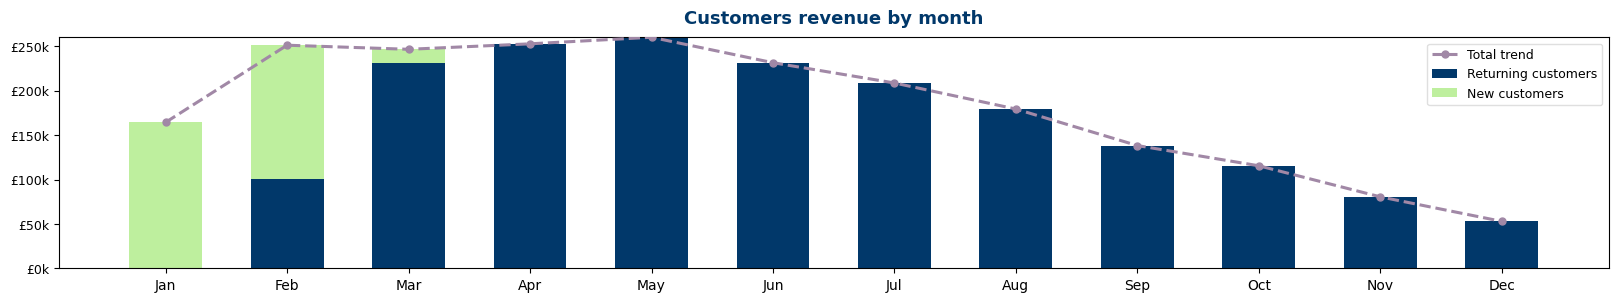

In [ ]:
# Monthly revenue (new vs returning customers)

# Preparing data for chart
first_purchase = (df.sort_values("invoice_date")
                    .groupby("customer_id")["invoice_date"]
                    .min()
                    .rename("first_date")
                    )

df2 = df.join(first_purchase, on="customer_id")
df2["month"]       = df2["invoice_date"].dt.to_period("M")
df2["first_month"] = df2["first_date"].dt.to_period("M")
df2["ctype"]       = np.where(df2["month"] == df2["first_month"], "New", "Returning")

monthly = (df2.groupby(["month","ctype"])["revenue"]
              .sum()
              .unstack(fill_value=0)
              .sort_index())

month_labels = [m.strftime("%b") for m in monthly.index.to_timestamp()]

# Showcase
fig, ax_month = plt.subplots(figsize=(20, 3))

x = np.arange(len(month_labels))
ret_vals = monthly.get("Returning", pd.Series([0]*len(monthly))).values
new_vals = monthly.get("New",       pd.Series([0]*len(monthly))).values
total_vals = ret_vals + new_vals

ax_month.bar(x, ret_vals, label="Returning customers",
             color=C_MAIN,   width=0.6, zorder=2)
ax_month.bar(x, new_vals,   bottom=ret_vals,
             label="New customers",
             color=C_THIRD,  width=0.6, zorder=2)

ax_month.plot(x, total_vals, color=C_SECOND, linewidth=2.2,
              linestyle="--", marker="o", markersize=5,
              label="Total trend", zorder=3)

ax_month.yaxis.set_major_formatter(mticker.FuncFormatter(gbp_k))
ax_month.set_xticks(x)
ax_month.set_xticklabels(month_labels, fontsize=10)
ax_month.tick_params(axis="y", labelsize=9)
ax_month.set_xlabel("")
ax_month.set_ylabel("")
ax_month.set_title("Customers revenue by month", fontsize=13, fontweight="bold",
                   color=C_MAIN, pad=10)
ax_month.legend(fontsize=9, loc="upper right", frameon=True,
                framealpha=0.92, edgecolor="#DDDDDD")

plt.savefig("Customers revenue by month.png")
plt.show()

## Modeling and evaluation

In [ ]:
# Seed
np.random.seed(42)

# Hyperparameters
MIN_SUPPORT = 0.003 # Minimum frequency of the product appereance required
METRIC = "confidence" # Measure quality to optimize (this one is confidence to the relationship)
MIN_CONFIDENCE = 0.05 # Minimum acceptable metric value

In [ ]:
# Creating the basket series
baskets = (df.groupby("invoice_no")["description"]
             .apply(list)
             .reset_index()
             .rename(columns={"description": "products"}))

# Showcase
baskets.head()

,invoice_no,products
0,500001,[DESK ORGANISER]
1,500002,"[WASHI TAPE SET, LUXURY NOTEBOOK, GIFT BAG LAR..."
2,500003,"[WIND CHIME, NOTEBOOK SET, STAMP SET, DESK ORG..."
3,500004,"[PEN SET LUXURY, SPICE RACK, SOAP SET]"
4,500005,"[WASHI TAPE SET, WATERING CAN]"


In [ ]:
# Basket insights
basket_sizes = baskets["products"].apply(len)
print(f"Total invoices          : {len(baskets):,}")
print(f"Avg products per basket : {basket_sizes.mean():.2f}")
print(f"Min / max basket size   : {basket_sizes.min()} / {basket_sizes.max()}")

Total invoices          : 16,851
Avg products per basket : 3.50
Min / max basket size   : 1 / 6


In [ ]:
# Train and test sets
train_baskets, test_baskets = train_test_split(
    baskets, test_size=0.2, random_state=42
)

# Showcase
train_baskets.head()

,invoice_no,products
8076,508077,"[CANDLE GIFT SET, GLASS STORAGE JAR, WALL HANG..."
8730,508731,"[AUTUMN WREATH, STORAGE BASKET, PAINT SET, COL..."
13683,513684,"[NOTEBOOK SET, TOWEL SET, SPICE RACK, METAL WA..."
1891,501892,"[RIBBON SPOOL, SEED PACKETS BUNDLE]"
7275,507276,"[CUSHION COVER, SUMMER BUNTING]"


In [ ]:
# Transaction Encoder (preprocessing)
te = TransactionEncoder()
te.fit(train_baskets["products"].tolist())

X_train = pd.DataFrame(
    te.transform(train_baskets["products"].tolist()),
    columns=te.columns_
)
X_test = pd.DataFrame(
    te.transform(test_baskets["products"].tolist(), sparse=False),
    columns=te.columns_
)

# Showcase
X_train.head()

,ADVENT CALENDAR,APRON,AUTUMN WREATH,BAKING MAT,BATH BOMB SET,BED RUNNER,BIRD FEEDER,BIRTHDAY BANNER,BOOKMARK SET,BUILDING BLOCKS,...,TISSUE PAPER PACK,TOWEL SET,TRINKET BOX,VALENTINES CARD SET,WALL HANGING,WASHI TAPE SET,WATERING CAN,WIND CHIME,WOODEN CUTTING BOARD,WOODEN PUZZLE
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Max single-product support
print(f"Max single-product support : {X_train.mean().max():.4f}")

Max single-product support : 0.0695


In [ ]:
# Training the Apriori
frequent_itemsets = apriori(
    X_train,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    verbose=0
)
frequent_itemsets.sort_values("support", ascending=False, inplace=True)
frequent_itemsets.reset_index(drop=True, inplace=True)

# Showcase
frequent_itemsets.head()

,support,itemsets
0,0.069510,(BATH BOMB SET)
1,0.067953,(TISSUE PAPER PACK)
2,0.067730,(RIBBON SPOOL)
3,0.067359,(PERSONALISED MUG)
4,0.067062,(PHOTO ALBUM)


In [ ]:
# Definiting the rules
asso_rules = association_rules(
    frequent_itemsets,
    metric=METRIC,
    min_threshold=MIN_CONFIDENCE,
    num_itemsets=len(frequent_itemsets)
)
rules_quality = asso_rules[asso_rules["lift"] >= 2.0].copy()
rules = rules_quality[["antecedents", "consequents", "support", "confidence", "lift"]]

In [ ]:
# Showcase from a sample
sample_rules = rules_quality.sample(min(20, len(rules)), random_state=42).reset_index(drop=True)
sample_rules.index += 1

display = sample_rules[["antecedents","consequents","support","confidence","lift"]].copy()
display["antecedents"] = display["antecedents"].apply(lambda x: ", ".join(sorted(x)))
display["consequents"] = display["consequents"].apply(lambda x: ", ".join(sorted(x)))
display["support"]     = display["support"].map("{:.4f}".format)
display["confidence"]  = display["confidence"].map("{:.3f}".format)
display["lift"]        = display["lift"].map("{:.2f}".format)

pd.set_option("display.max_colwidth", 30)
pd.set_option("display.width", 130)
print(display.to_string())

             antecedents           consequents support confidence  lift
1           WALL HANGING         CUSHION COVER  0.0039      0.084  2.02
2          AUTUMN WREATH       ADVENT CALENDAR  0.0049      0.117  2.69
3         SUMMER BUNTING  HALLOWEEN DECORATION  0.0047      0.112  2.77
4             BED RUNNER         CUSHION COVER  0.0032      0.084  2.01
5          PLACEMATS SET    DECORATIVE LANTERN  0.0030      0.085  2.07
6        GIFT WRAP SHEET         WOODEN PUZZLE  0.0036      0.070  2.14
7         CRAFT KIT KIDS             STAMP SET  0.0041      0.129  2.66
8      FINGER PUPPET SET             CARD GAME  0.0031      0.101  3.14
9   CHRISTMAS BAUBLE SET    COLOURING BOOK SET  0.0031      0.073  2.45
10          NOTEBOOK SET        WASHI TAPE SET  0.0045      0.094  2.00
11          FAIRY LIGHTS       ADVENT CALENDAR  0.0041      0.095  2.20
12    COLOURING BOOK SET       GIFT WRAP SHEET  0.0032      0.107  2.05
13        CRAFT KIT KIDS          NOTEBOOK SET  0.0031      0.09

In [ ]:
# Evaluation of rules
print(f"\nHigh-quality rules (lift >= 2.0): {len(rules_quality):,} of {len(asso_rules):,} total")
print(f"  These are rules where product B appears 2x more likely when A is present.")
print(f"  Avg support    : {rules['support'].mean():.4f}")
print(f"  Avg confidence : {rules['confidence'].mean():.3f}")
print(f"  Avg lift       : {rules['lift'].mean():.2f}")


High-quality rules (lift >= 2.0): 202 of 943 total
  These are rules where product B appears 2x more likely when A is present.
  Avg support    : 0.0039
  Avg confidence : 0.095
  Avg lift       : 2.35


In [ ]:
# Top products (in case of no matching rules)
top3 = frequent_itemsets.head(3).copy()
top3["itemsets"] = top3["itemsets"].apply(lambda x: ", ".join(sorted(x)))
print(top3[["support","itemsets"]].to_string(index=False))

 support          itemsets
0.069510     BATH BOMB SET
0.067953 TISSUE PAPER PACK
0.067730      RIBBON SPOOL


In [ ]:
# Recommendation function
def recommend(basket_items: list, rules_df: pd.DataFrame, top_n: int = 5) -> list:
    """
    Given products already in a basket, return top-N recommendations
    by finding rules whose antecedent is a subset of the basket,
    then ranking matched consequents by lift then confidence.
    """
    basket_set = set(basket_items)
    matched = rules_df[
        rules_df["antecedents"].apply(lambda a: a.issubset(basket_set))
    ]
    if matched.empty:
        return top3["itemsets"].tolist()
    recs = (matched.explode("consequents")
                   .query("consequents not in @basket_set")
                   .sort_values(["lift","confidence"], ascending=False)
                   .drop_duplicates("consequents")
                   .head(top_n)["consequents"]
                   .tolist()[:3])
    return recs

In [ ]:
# Evaluation
def evaluate(test_df: pd.DataFrame,
             rules_df: pd.DataFrame,
             top_n: int = 5) -> dict:
    """
    Split each test basket 50/50:
      input  = first half  (simulates user viewing a product page)
      ground = second half (held-out actual purchases)
    Metrics:
      Coverage    : % baskets where >= 1 rec was produced
      Hit Rate    : % baskets where >= 1 rec matched ground truth
      Precision@N : avg fraction of top-N recs that matched ground truth
    """
    hits, precision_scores = 0, []
    covered, total = 0, 0

    for _, row in test_df.iterrows():
        items = row["products"]
        if len(items) < 2:
            continue
        total += 1
        mid          = max(1, len(items) // 2)
        input_items  = items[:mid]
        ground_truth = set(items[mid:])

        recs = recommend(input_items, rules_df, top_n=top_n)

        if recs:
            covered += 1
            hit      = any(r in ground_truth for r in recs)
            hits     += int(hit)
            precision_scores.append(len(set(recs) & ground_truth) / top_n)

    return {
        "total":     total,
        "coverage":  covered / total if total else 0,
        "hit_rate":  hits / total if total else 0,
        "precision": np.mean(precision_scores) if precision_scores else 0,
        "top_n":     top_n,
    }


res = evaluate(test_baskets, rules)

In [ ]:
# Results of test set
res

{'total': 2778,
 'coverage': 0.9992800575953924,
 'hit_rate': 0.1263498920086393,
 'precision': np.float64(0.02622478386167147),
 'top_n': 5}

In [ ]:
# Model in production
for seed in [7, 13, 21]:
    row      = test_baskets.sample(1, random_state=seed).iloc[0]
    input_p  = row["products"][:2]
    recs     = recommend(input_p, rules, top_n=5)
    print(f"\n  Input : {input_p}")
    print(f"  Recs  : {recs}")


  Input : ['COLANDER', 'CAKE TIN SET']
  Recs  : ['BATH BOMB SET', 'TISSUE PAPER PACK', 'RIBBON SPOOL']

  Input : ['THROW BLANKET', 'METAL WALL CLOCK']
  Recs  : ['TABLE RUNNER', 'TOWEL SET', 'WALL HANGING']

  Input : ['JIGSAW 500PC', 'ADVENT CALENDAR']
  Recs  : ['HALLOWEEN DECORATION', 'AUTUMN WREATH', 'VALENTINES CARD SET']


## Deployment

In [ ]:
# Serializing the frequent items and rules
with open("frequent_items.pkl", "wb") as f:
  pickle.dump(frequent_itemsets, f)

with open("asso_rules.pkl", "wb") as f:
  pickle.dump(rules, f)